=== RISULTATI DEL TRASPORTO ===
Sigma_xx  = 0.191656
Sigma_xy  = 0.039881
cot(TH)   = 4.805682  (Cotangente di Hall)
R_H (prop)= 1.085730  (Proporzionale al Coeff. di Hall)



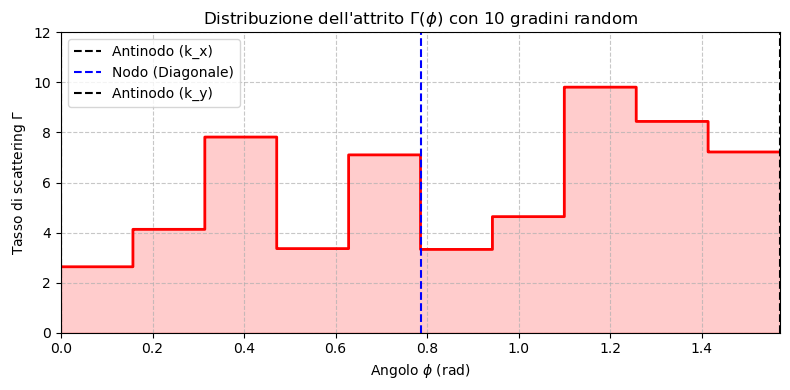

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI
# ==========================================
Gamma1 = 1.0  # Attrito minimo
Gamma2 = 10.0 # Attrito massimo (hot-spot)

# Definiamo la geometria del nostro quadrante (da 0 a pi/2)
N_steps = 10  # Numero di gradini (intervalli)
phi_max = np.pi / 2
N_points = 100000  # Griglia super-fitta per gestire bene la derivata dei gradini

# Creiamo l'asse degli angoli
phi = np.linspace(0, phi_max, N_points)

# ==========================================
# 2. COSTRUZIONE DI GAMMA(phi) RANDOM
# ==========================================
# Creiamo i bordi degli intervalli
step_edges = np.linspace(0, phi_max, N_steps + 1)
# Estraiamo un valore casuale tra Gamma1 e Gamma2 per ogni gradino
random_gammas = np.random.uniform(Gamma1, Gamma2, N_steps)

# Riempiamo l'array Gamma_phi
Gamma_phi = np.zeros_like(phi)
for i in range(N_steps):
    # Seleziona gli indici che cadono in questo specifico intervallo
    mask = (phi >= step_edges[i]) & (phi <= step_edges[i+1])
    Gamma_phi[mask] = random_gammas[i]

# ==========================================
# 3. CALCOLO NUMERICO DEGLI INTEGRALI
# ==========================================

# --- Calcolo di Sigma_xx ---
# Integrale di: cos^2(phi) / Gamma(phi)
integrand_xx = (np.cos(phi)**2) / Gamma_phi
sigma_xx = np.trapz(integrand_xx, phi)

# --- Calcolo di Sigma_xy ---
# Integrale di: [cos(phi) / Gamma(phi)] * d/dphi[sin(phi) / Gamma(phi)]
term_to_derive = np.sin(phi) / Gamma_phi
derivative_term = np.gradient(term_to_derive, phi)  # Calcolo numerico della derivata

integrand_xy = (np.cos(phi) / Gamma_phi) * derivative_term
sigma_xy = np.trapz(integrand_xy, phi)

# ==========================================
# 4. RISULTATI E PLOT
# ==========================================
print("=== RISULTATI DEL TRASPORTO ===")
print(f"Sigma_xx  = {sigma_xx:.6f}")
print(f"Sigma_xy  = {sigma_xy:.6f}")
print(f"cot(TH)   = {sigma_xx / sigma_xy:.6f}  (Cotangente di Hall)")
print(f"R_H (prop)= {sigma_xy / (sigma_xx**2):.6f}  (Proporzionale al Coeff. di Hall)\n")

# Visualizzazione della mappa di attrito
plt.figure(figsize=(8, 4))
plt.plot(phi, Gamma_phi, drawstyle='steps-mid', color='red', linewidth=2)
plt.fill_between(phi, Gamma_phi, color='red', alpha=0.2)
plt.title(f'Distribuzione dell\'attrito $\Gamma(\phi)$ con {N_steps} gradini random')
plt.xlabel('Angolo $\phi$ (rad)')
plt.ylabel('Tasso di scattering $\Gamma$')
plt.xlim(0, phi_max)
plt.ylim(0, Gamma2 + 2)
plt.grid(True, linestyle='--', alpha=0.7)

# Segniamo gli assi (antinodi/nodi)
plt.axvline(0, color='black', linestyle='--', label='Antinodo (k_x)')
plt.axvline(np.pi/4, color='blue', linestyle='--', label='Nodo (Diagonale)')
plt.axvline(np.pi/2, color='black', linestyle='--', label='Antinodo (k_y)')
plt.legend()
plt.tight_layout()
plt.show()

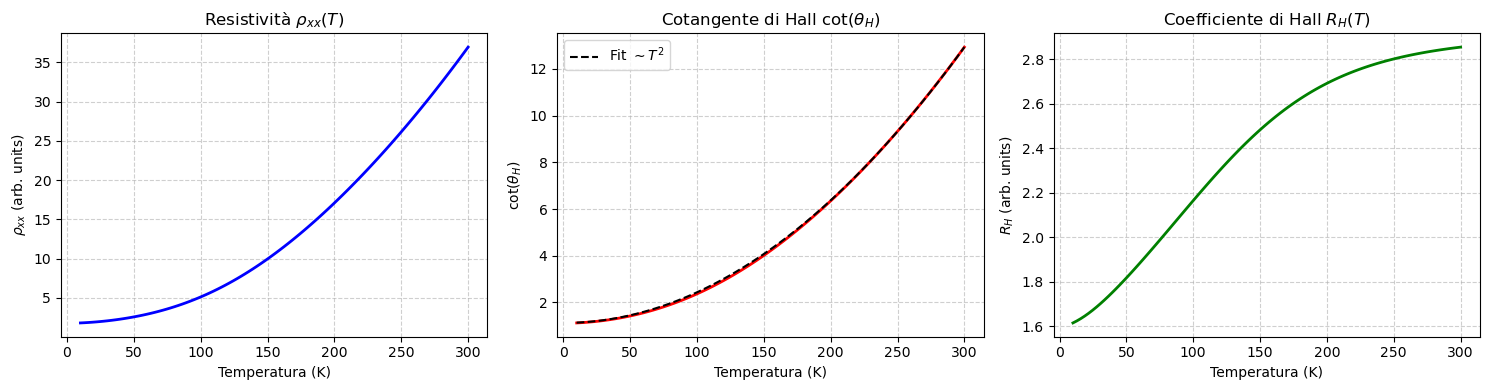

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI FISICI
# ==========================================
# Vettori delle temperature (es. da 10 K a 300 K)
T_array = np.linspace(10, 300, 100)

# Griglia degli angoli (un quadrante)
phi_max = np.pi / 2
N_points = 50000 
phi = np.linspace(0, phi_max, N_points)

# Array per salvare i risultati
rho_xx = np.zeros_like(T_array)
sigma_xy_arr = np.zeros_like(T_array)
cot_theta = np.zeros_like(T_array)
R_H = np.zeros_like(T_array)

# ==========================================
# 2. LOOP SULLA TEMPERATURA
# ==========================================
for i, T in enumerate(T_array):
    
    # --- Modello Fenomenologico T-dependent (stile Götz / Caprara) ---
    # 1. L'attrito ai nodi cresce come T^2 (liquido di Fermi standard)
    Gamma_nodo = 1.0 + 0.0001 * (T**2)
    
    # 2. L'attrito agli antinodi è molto più forte e cresce anch'esso
    Gamma_antinodo = 10.0 + 0.005 * (T**2)
    
    # 3. La "dimensione" dell'hot-spot. 
    # Usiamo un parametro nu(T). Se nu è piccolo, l'hot-spot è largo.
    # Simuliamo il phi_1(T) di Götz allargando l'hot-spot all'aumentare di T
    # (nu diminuisce saturando a un valore minimo)
    nu_T = 20.0 - 15.0 * np.tanh(T / 100.0) 
    
    # Costruiamo il profilo di scattering per questa temperatura
    # |cos(2*phi)|^nu crea dei picchi centrati in 0 e pi/2 (gli antinodi)
    Gamma_phi = Gamma_nodo + Gamma_antinodo * (np.abs(np.cos(2*phi))**nu_T)
    
    # --- Calcolo degli integrali (BTE) ---
    # Sigma_xx
    integrand_xx = (np.cos(phi)**2) / Gamma_phi
    s_xx = np.trapz(integrand_xx, phi)
    
    # Sigma_xy (Conducibilità di Hall)
    term_to_derive = np.sin(phi) / Gamma_phi
    derivative_term = np.gradient(term_to_derive, phi)
    integrand_xy = (np.cos(phi) / Gamma_phi) * derivative_term
    s_xy = np.trapz(integrand_xy, phi)
    
    # --- Salvataggio delle grandezze macroscopiche ---
    rho_xx[i] = 1.0 / s_xx
    sigma_xy_arr[i] = s_xy
    cot_theta[i] = s_xx / s_xy
    R_H[i] = s_xy / (s_xx**2)

# ==========================================
# 3. PLOT DEI RISULTATI
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Resistività Longitudinale (rho_xx ~ T)
axs[0].plot(T_array, rho_xx, 'b-', lw=2)
axs[0].set_title(r'Resistività $\rho_{xx}(T)$')
axs[0].set_xlabel('Temperatura (K)')
axs[0].set_ylabel(r'$\rho_{xx}$ (arb. units)')
axs[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Cotangente di Hall (cot_theta_H ~ T^2)
axs[1].plot(T_array, cot_theta, 'r-', lw=2)
# Aggiungiamo un fit T^2 per confronto visivo
fit_T2 = cot_theta[0] + (cot_theta[-1]-cot_theta[0]) * (T_array/T_array[-1])**2
axs[1].plot(T_array, fit_T2, 'k--', label=r'Fit $\sim T^2$')
axs[1].set_title(r'Cotangente di Hall $\cot(\theta_H)$')
axs[1].set_xlabel('Temperatura (K)')
axs[1].set_ylabel(r'$\cot(\theta_H)$')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Coefficiente di Hall (R_H scende e satura)
axs[2].plot(T_array, R_H, 'g-', lw=2)
axs[2].set_title(r'Coefficiente di Hall $R_H(T)$')
axs[2].set_xlabel('Temperatura (K)')
axs[2].set_ylabel(r'$R_H$ (arb. units)')
axs[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

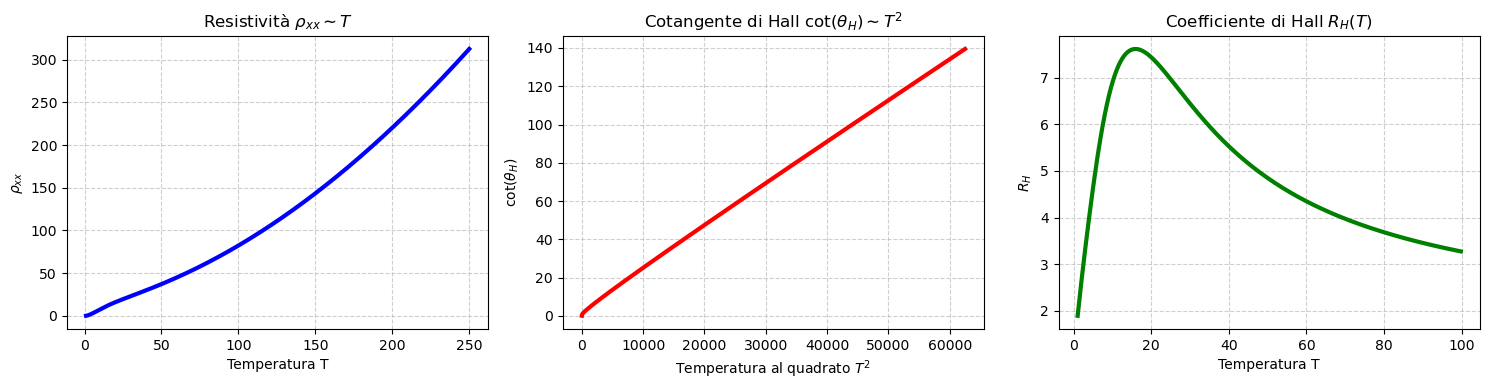

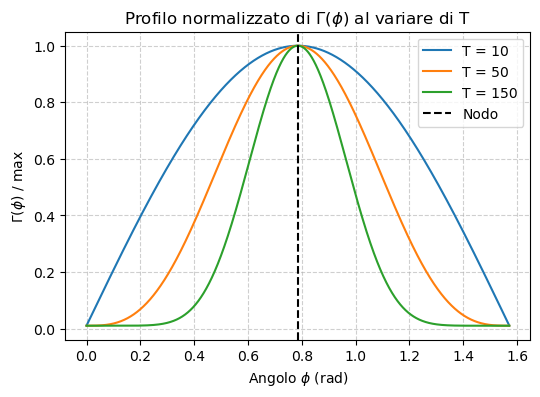

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI
# ==========================================
# Creiamo il vettore delle temperature
T_array = np.linspace(1, 250, 500)

# Griglia degli angoli sul primo quadrante
phi_max = np.pi / 2
N_points = 50000 
phi = np.linspace(0, phi_max, N_points)

# Array per i risultati
rho_xx = np.zeros_like(T_array)
sigma_xy_arr = np.zeros_like(T_array)
cot_theta = np.zeros_like(T_array)
R_H = np.zeros_like(T_array)

# ==========================================
# 2. LOOP SULLA TEMPERATURA
# ==========================================
for i, T in enumerate(T_array):
    
    # 1. L'attrito minimo cresce come T^2
    Gamma_cold = 0.002 * (T**2) + 0.01  # +0.01 per evitare divisioni per zero
    
    # 2. L'attrito massimo cresce come T^2 ed è 100 volte più forte
    Gamma_hot = 0.2 * (T**2)
    
    # 3. L'espansione del cold-spot. 
    # Usiamo un esponente nu(T) che cresce con T. 
    # Più nu è grande, più la funzione |sin(2x)|^nu rimane vicina a zero,
    # "allargando" la regione fredda agli antinodi (replicando phi_1 ~ T).
    nu_T = 0.5 + (T / 20.0) 
    
    # Costruiamo la funzione continua Gamma(phi)
    # Il seno posiziona l'hot-spot a pi/4 (nodo) e il cold-spot a 0 e pi/2 (antinodi)
    Gamma_phi = Gamma_cold + Gamma_hot * (np.abs(np.sin(2*phi))**nu_T)
    
    # --- Calcolo degli integrali di Boltzmann ---
    
    # Sigma_xx
    integrand_xx = (np.cos(phi)**2) / Gamma_phi
    s_xx = np.trapz(integrand_xx, phi)
    
    # Sigma_xy (usiamo la derivata numerica come avevamo fatto)
    term_to_derive = np.sin(phi) / Gamma_phi
    derivative_term = np.gradient(term_to_derive, phi)
    integrand_xy = (np.cos(phi) / Gamma_phi) * derivative_term
    s_xy = np.trapz(integrand_xy, phi)
    
    # --- Calcolo Grandezze Macroscopiche ---
    rho_xx[i] = 1.0 / s_xx
    sigma_xy_arr[i] = s_xy
    cot_theta[i] = s_xx / s_xy
    R_H[i] = s_xy / (s_xx**2)

# ==========================================
# 3. PLOT DEI RISULTATI
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Resistività Longitudinale (rho_xx ~ T)
axs[0].plot(T_array, rho_xx, 'b-', lw=3)
axs[0].set_title(r'Resistività $\rho_{xx} \sim T$')
axs[0].set_xlabel('Temperatura T')
axs[0].set_ylabel(r'$\rho_{xx}$')
axs[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Cotangente di Hall (cot_theta_H ~ T^2)
axs[1].plot(T_array**2, cot_theta, 'r-', lw=3) # Plotto contro T^2 per mostrare che è una retta
axs[1].set_title(r'Cotangente di Hall $\cot(\theta_H) \sim T^2$')
axs[1].set_xlabel('Temperatura al quadrato $T^2$')
axs[1].set_ylabel(r'$\cot(\theta_H)$')
axs[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Coefficiente di Hall (R_H scende)
mask = T_array <= 100 # Mostriamo solo fino a T=100 come nella slide di Götz
axs[2].plot(T_array[mask], R_H[mask], 'g-', lw=3)
axs[2].set_title(r'Coefficiente di Hall $R_H(T)$')
axs[2].set_xlabel('Temperatura T')
axs[2].set_ylabel(r'$R_H$')
axs[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ==========================================
# 4. PLOT BONUS: Come cambia Gamma(phi) con T?
# ==========================================
plt.figure(figsize=(6, 4))
for T_test in [10, 50, 150]:
    Gamma_c = 0.002 * (T_test**2) + 0.01
    Gamma_h = 0.2 * (T_test**2)
    nu_T = 0.5 + (T_test / 20.0)
    G_phi = Gamma_c + Gamma_h * (np.abs(np.sin(2*phi))**nu_T)
    # Normalizziamo per visualizzare le forme geometriche indipendentemente dall'ampiezza T^2
    plt.plot(phi, G_phi/np.max(G_phi), label=f'T = {T_test}')

plt.title('Profilo normalizzato di $\Gamma(\phi)$ al variare di T')
plt.xlabel('Angolo $\phi$ (rad)')
plt.ylabel('$\Gamma(\phi)$ / max')
plt.axvline(np.pi/4, color='black', linestyle='--', label='Nodo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

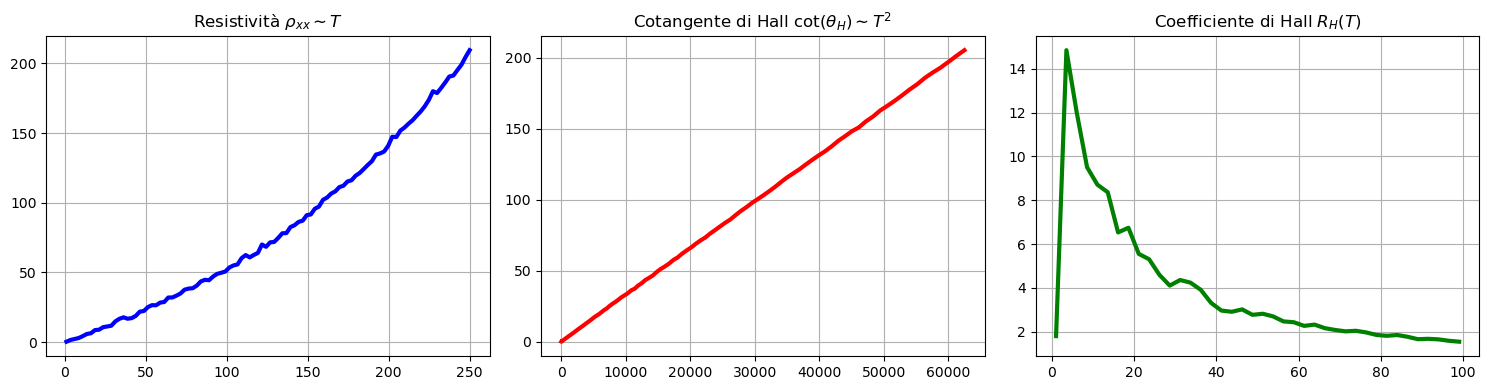

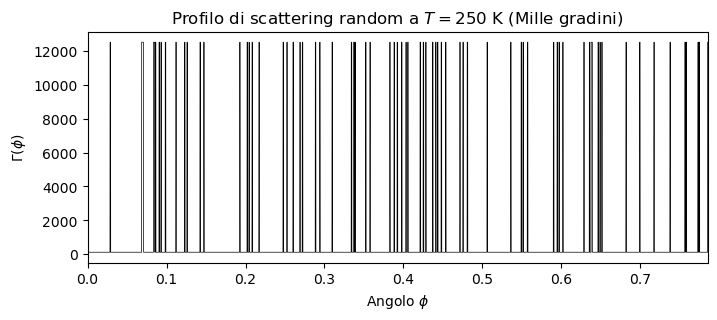

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI E GRIGLIA
# ==========================================
T_array = np.linspace(1, 250, 100)

# Griglia perfetta: 1000 bin tra 0 e pi/4.
# Mettiamo 100 punti dentro ogni bin per avere derivate numeriche stabili
N_bins = 1000
points_per_bin = 100

N_points_q1 = N_bins * points_per_bin   # Punti in [0, pi/4]
N_points_total = N_points_q1 * 2        # Punti in [0, pi/2]

# Creiamo l'asse phi (endpoint=False evita disallineamenti della griglia)
phi = np.linspace(0, np.pi/2, N_points_total, endpoint=False)

# Array per i risultati
rho_xx = np.zeros_like(T_array)
sigma_xy_arr = np.zeros_like(T_array)
cot_theta = np.zeros_like(T_array)
R_H = np.zeros_like(T_array)

# ==========================================
# 2. LOOP SULLA TEMPERATURA
# ==========================================
for i, T in enumerate(T_array):
    
    # 1. Background a T^2
    Gamma_1 = 0.002 * (T**2) + 0.01  # Cold-spot
    Gamma_2 = 0.2 * (T**2)           # Hot-spot
    
    # 2. La frazione (probabilità) di cold-spot cresce con T
    # Sostituisce l'allargamento dell'angolo di Götz
    p_cold = np.tanh(T / 150.0) 
    
    # 3. Generazione dei 1000 gradini random tra 0 e pi/4
    # Sceglie Gamma_1 con probabilità p_cold, altrimenti Gamma_2
    choices = np.random.choice([Gamma_1, Gamma_2], size=N_bins, p=[p_cold, 1-p_cold])
    
    # Riempiamo la prima metà dell'array phi (da 0 a pi/4) ripetendo ogni scelta
    Gamma_q1 = np.repeat(choices, points_per_bin)
    
    # La seconda metà (da pi/4 a pi/2) resta a Gamma_2 (l'hot spot puro vicino all'asse y)
    Gamma_q2 = np.full(N_points_q1, Gamma_2)
    
    # Uniamo le due metà
    Gamma_phi = np.concatenate([Gamma_q1, Gamma_q2])
    
    # --- Calcolo degli integrali di Boltzmann ---
    
    # Sigma_xx
    integrand_xx = (np.cos(phi)**2) / Gamma_phi
    s_xx = np.trapz(integrand_xx, phi)
    
    # Sigma_xy
    term_to_derive = np.sin(phi) / Gamma_phi
    derivative_term = np.gradient(term_to_derive, phi)
    integrand_xy = (np.cos(phi) / Gamma_phi) * derivative_term
    s_xy = np.trapz(integrand_xy, phi)
    
    # Salvataggio
    rho_xx[i] = 1.0 / s_xx
    sigma_xy_arr[i] = s_xy
    cot_theta[i] = s_xx / s_xy
    R_H[i] = s_xy / (s_xx**2)

# ==========================================
# 3. PLOT DEI RISULTATI
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(T_array, rho_xx, 'b-', lw=3)
axs[0].set_title(r'Resistività $\rho_{xx} \sim T$')
axs[0].grid(True)

axs[1].plot(T_array**2, cot_theta, 'r-', lw=3) 
axs[1].set_title(r'Cotangente di Hall $\cot(\theta_H) \sim T^2$')
axs[1].grid(True)

mask = T_array <= 100
axs[2].plot(T_array[mask], R_H[mask], 'g-', lw=3)
axs[2].set_title(r'Coefficiente di Hall $R_H(T)$')
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. PLOT DELLA MAPPA DI ATTRITO (Zoom su 0 -> pi/4)
# ==========================================
plt.figure(figsize=(8, 3))
plt.plot(phi, Gamma_phi, 'k-', lw=0.5)
plt.title('Profilo di scattering random a $T = 250$ K (Mille gradini)')
plt.xlim(0, np.pi/4)
plt.xlabel('Angolo $\phi$')
plt.ylabel('$\Gamma(\phi)$')
plt.show()

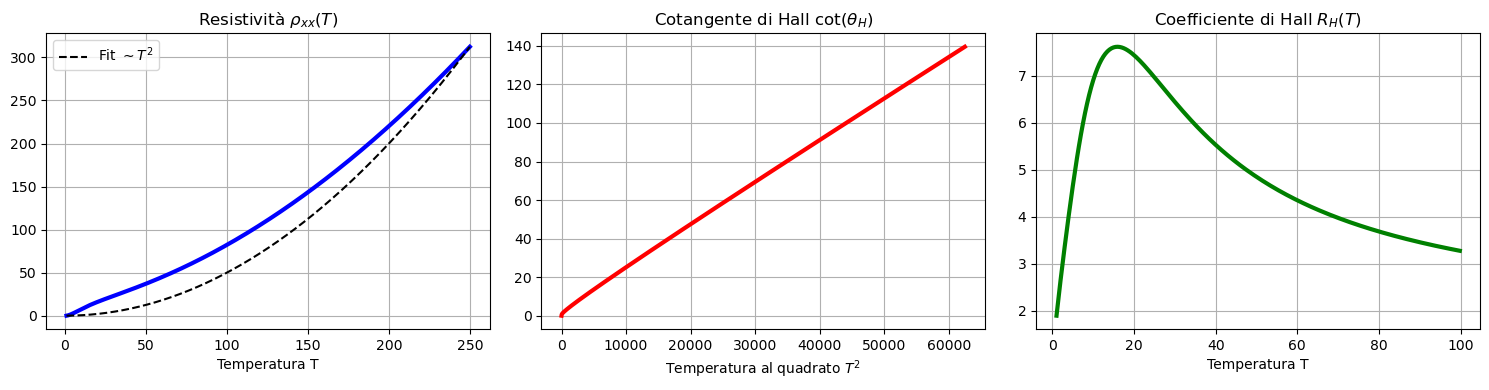

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI
# ==========================================
T_array = np.linspace(1, 250, 500)

phi_max = np.pi / 2
N_points = 50000 
phi = np.linspace(0, phi_max, N_points)

rho_xx = np.zeros_like(T_array)
sigma_xy_arr = np.zeros_like(T_array)
cot_theta = np.zeros_like(T_array)
R_H = np.zeros_like(T_array)

# ==========================================
# 2. LOOP SULLA TEMPERATURA
# ==========================================
for i, T in enumerate(T_array):
    
    # Background puramente T^2 per entrambi i tassi
    Gamma_cold = 0.002 * (T**2) + 0.01  # Attrito debole
    Gamma_hot = 0.2 * (T**2)            # Attrito forte (hot-spot)
    
    # Allargamento dell'hot-spot (o del cold-spot)
    nu_T = 0.5 + (T / 20.0) 
    
    # LA MODIFICA CRUCIALE: usiamo COSENO
    # Ora l'hot-spot (Gamma_hot) è a phi=0 e phi=pi/2 (Antinodi)
    # Il cold-spot (Gamma_cold) è a phi=pi/4 (Nodo)
    Gamma_phi = Gamma_cold + Gamma_hot * (np.abs(np.cos(2*phi))**nu_T)
    
    # --- Integrali di Boltzmann ---
    integrand_xx = (np.cos(phi)**2) / Gamma_phi
    s_xx = np.trapz(integrand_xx, phi)
    
    term_to_derive = np.sin(phi) / Gamma_phi
    derivative_term = np.gradient(term_to_derive, phi)
    integrand_xy = (np.cos(phi) / Gamma_phi) * derivative_term
    s_xy = np.trapz(integrand_xy, phi)
    
    # --- Grandezze Macroscopiche ---
    rho_xx[i] = 1.0 / s_xx
    sigma_xy_arr[i] = s_xy
    cot_theta[i] = s_xx / s_xy
    R_H[i] = s_xy / (s_xx**2)

# ==========================================
# 3. PLOT DEI RISULTATI
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Resistività
axs[0].plot(T_array, rho_xx, 'b-', lw=3)
# Aggiungiamo un fit T^2 per mostrare la differenza
fit_T2 = rho_xx[0] + (rho_xx[-1]-rho_xx[0]) * (T_array/T_array[-1])**2
axs[0].plot(T_array, fit_T2, 'k--', label=r'Fit $\sim T^2$')
axs[0].set_title(r'Resistività $\rho_{xx}(T)$')
axs[0].set_xlabel('Temperatura T')
axs[0].legend()
axs[0].grid(True)

# Plot 2: Cotangente di Hall
axs[1].plot(T_array**2, cot_theta, 'r-', lw=3) 
axs[1].set_title(r'Cotangente di Hall $\cot(\theta_H)$')
axs[1].set_xlabel('Temperatura al quadrato $T^2$')
axs[1].grid(True)

# Plot 3: Coefficiente di Hall
mask = T_array <= 100
axs[2].plot(T_array[mask], R_H[mask], 'g-', lw=3)
axs[2].set_title(r'Coefficiente di Hall $R_H(T)$')
axs[2].set_xlabel('Temperatura T')
axs[2].grid(True)

plt.tight_layout()
plt.show()

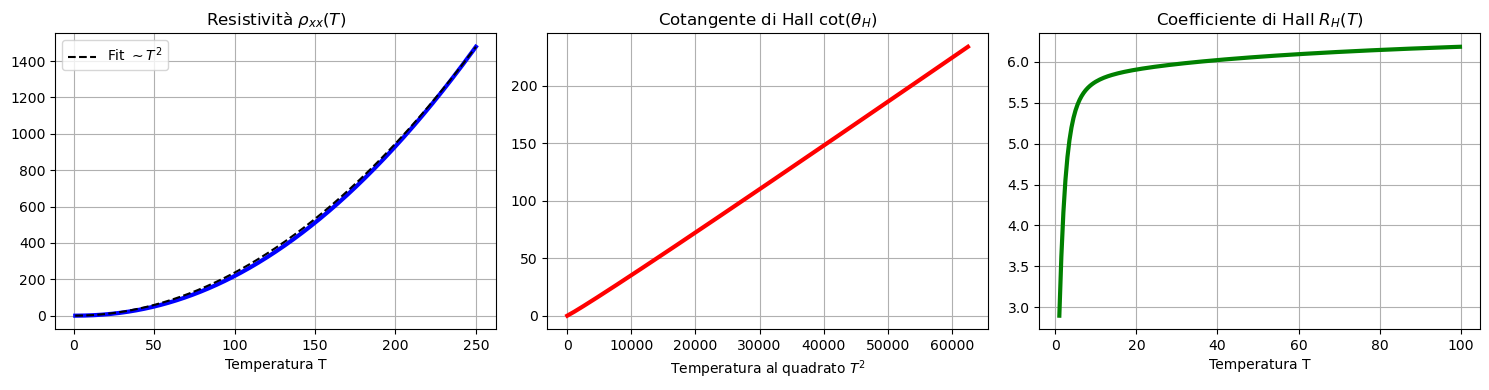

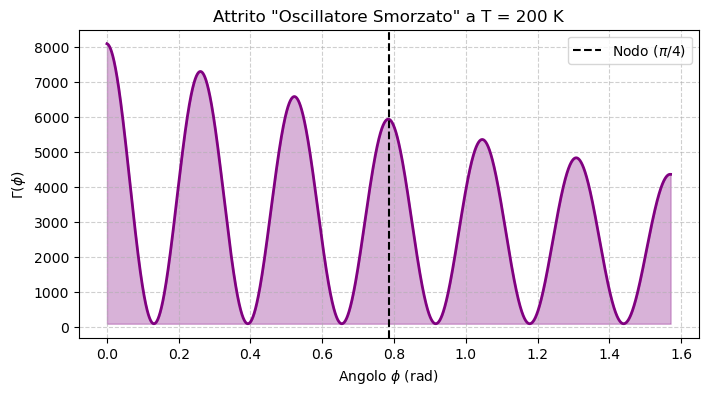

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI
# ==========================================
T_array = np.linspace(1, 250, 500)

phi_max = np.pi / 2
N_points = 50000 
phi = np.linspace(0, phi_max, N_points)

rho_xx = np.zeros_like(T_array)
sigma_xy_arr = np.zeros_like(T_array)
cot_theta = np.zeros_like(T_array)
R_H = np.zeros_like(T_array)

# ==========================================
# 2. LOOP SULLA TEMPERATURA
# ==========================================
for i, T in enumerate(T_array):
    
    # 1. Background termodinamico a T^2
    Gamma_bg = 0.002 * (T**2) + 0.01  
    
    # 2. L'ampiezza massima dell'oscillatore (hot-spot principale) a T^2
    A = 0.2 * (T**2)
    
    # 3. Parametri dell'oscillatore smorzato
    omega = 12.0  # Frequenza: crea diverse "increspature" tra 0 e pi/2
    
    # Lo smorzamento (damping) varia con T. 
    # Ad alte T l'esponenziale decade meno velocemente (si propaga di più)
    gamma = 2.0 / (1.0 + T/50.0) 
    
    # LA FUNZIONE "STRANA": Oscillatore Armonico Smorzato
    # Ha il picco massimo a phi=0, poi oscilla decadendo verso pi/2
    Gamma_phi = Gamma_bg + A * np.exp(-gamma * phi) * (np.cos(omega * phi)**2)
    
    # --- Calcolo degli integrali di Boltzmann ---
    integrand_xx = (np.cos(phi)**2) / Gamma_phi
    s_xx = np.trapz(integrand_xx, phi)
    
    term_to_derive = np.sin(phi) / Gamma_phi
    derivative_term = np.gradient(term_to_derive, phi)
    integrand_xy = (np.cos(phi) / Gamma_phi) * derivative_term
    s_xy = np.trapz(integrand_xy, phi)
    
    # --- Salvataggio Grandezze Macroscopiche ---
    rho_xx[i] = 1.0 / s_xx
    sigma_xy_arr[i] = s_xy
    cot_theta[i] = s_xx / s_xy
    R_H[i] = s_xy / (s_xx**2)

# ==========================================
# 3. PLOT DEI RISULTATI MACROSCOPICI
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(T_array, rho_xx, 'b-', lw=3)
fit_T2 = rho_xx[0] + (rho_xx[-1]-rho_xx[0]) * (T_array/T_array[-1])**2
axs[0].plot(T_array, fit_T2, 'k--', label=r'Fit $\sim T^2$')
axs[0].set_title(r'Resistività $\rho_{xx}(T)$')
axs[0].set_xlabel('Temperatura T')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(T_array**2, cot_theta, 'r-', lw=3) 
axs[1].set_title(r'Cotangente di Hall $\cot(\theta_H)$')
axs[1].set_xlabel('Temperatura al quadrato $T^2$')
axs[1].grid(True)

mask = T_array <= 100
axs[2].plot(T_array[mask], R_H[mask], 'g-', lw=3)
axs[2].set_title(r'Coefficiente di Hall $R_H(T)$')
axs[2].set_xlabel('Temperatura T')
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. PLOT BONUS: Guarda la forma dell'attrito!
# ==========================================
plt.figure(figsize=(8, 4))
T_test = 200
Gamma_bg = 0.002 * (T_test**2) + 0.01  
A = 0.2 * (T_test**2)
omega = 12.0  
gamma = 2.0 / (1.0 + T_test/50.0) 
G_phi = Gamma_bg + A * np.exp(-gamma * phi) * (np.cos(omega * phi)**2)

plt.plot(phi, G_phi, 'purple', lw=2)
plt.fill_between(phi, G_phi, Gamma_bg, color='purple', alpha=0.3)
plt.title(f'Attrito "Oscillatore Smorzato" a T = {T_test} K')
plt.xlabel('Angolo $\phi$ (rad)')
plt.ylabel('$\Gamma(\phi)$')
plt.axvline(np.pi/4, color='black', linestyle='--', label='Nodo ($\pi/4$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

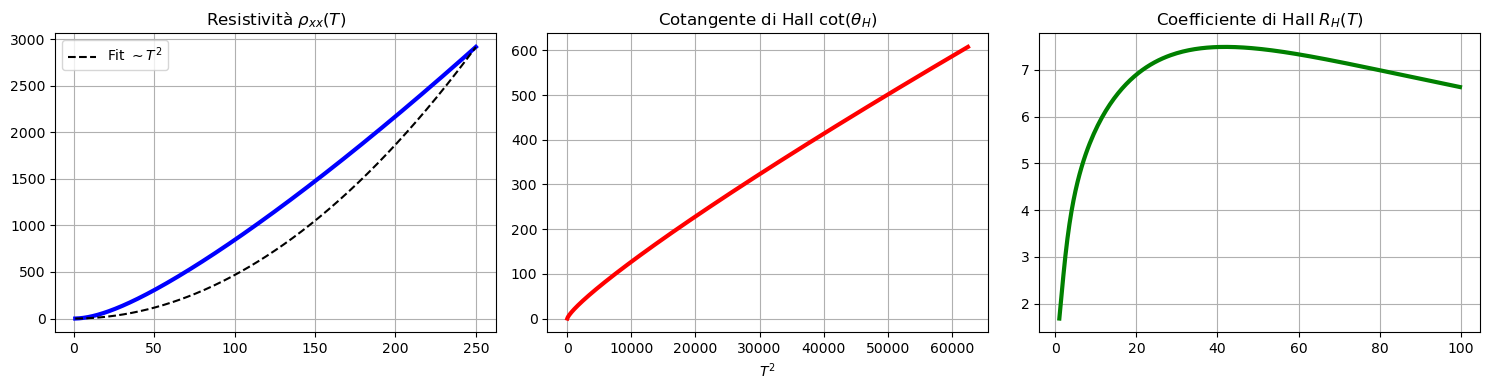

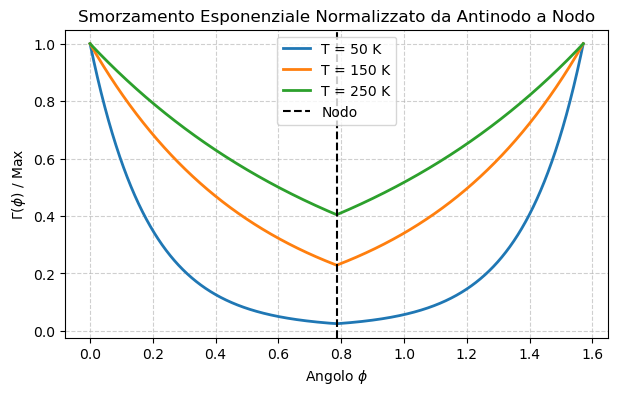

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI
# ==========================================
T_array = np.linspace(1, 250, 500)

phi_max = np.pi / 2
N_points = 50000 
phi = np.linspace(0, phi_max, N_points)

# Distanza dal più vicino antinodo (0 oppure pi/2)
# Serve per fare uno smorzamento simmetrico verso il nodo a pi/4
dist_antinodo = np.minimum(phi, np.pi/2 - phi)

rho_xx = np.zeros_like(T_array)
sigma_xy_arr = np.zeros_like(T_array)
cot_theta = np.zeros_like(T_array)
R_H = np.zeros_like(T_array)

# ==========================================
# 2. LOOP SULLA TEMPERATURA
# ==========================================
for i, T in enumerate(T_array):
    
    # Entrambi gli attriti scalano quadraticamente (Liquido di Fermi)
    Gamma_cold = 0.2 * (T**2)           # Valore all'antinodo (phi=0, pi/2)
    Gamma_hot = 0.002 * (T**2) + 0.01 # Valore al nodo (phi=pi/4)
    
    # Lunghezza di smorzamento che cresce con T
    # Sostituisce l'angolo di crossover phi_1(T)
    L_T = 0.02 + (T / 300.0) 
    
    # FUNZIONE DI SMORZAMENTO ESPONENZIALE
    # Parte da Gamma_hot e decade verso Gamma_cold
    Gamma_phi = Gamma_cold + (Gamma_hot - Gamma_cold) * np.exp(-dist_antinodo / L_T)
    
    # --- Integrali di Boltzmann ---
    integrand_xx = (np.cos(phi)**2) / Gamma_phi
    s_xx = np.trapz(integrand_xx, phi)
    
    term_to_derive = np.sin(phi) / Gamma_phi
    derivative_term = np.gradient(term_to_derive, phi)
    integrand_xy = (np.cos(phi) / Gamma_phi) * derivative_term
    s_xy = np.trapz(integrand_xy, phi)
    
    # --- Grandezze Macroscopiche ---
    rho_xx[i] = 1.0 / s_xx
    sigma_xy_arr[i] = s_xy
    cot_theta[i] = s_xx / s_xy
    R_H[i] = s_xy / (s_xx**2)

# ==========================================
# 3. PLOT DEI RISULTATI
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(T_array, rho_xx, 'b-', lw=3)
fit_T2 = rho_xx[0] + (rho_xx[-1]-rho_xx[0]) * (T_array/T_array[-1])**2
axs[0].plot(T_array, fit_T2, 'k--', label=r'Fit $\sim T^2$')
axs[0].set_title(r'Resistività $\rho_{xx}(T)$')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(T_array**2, cot_theta, 'r-', lw=3) 
axs[1].set_title(r'Cotangente di Hall $\cot(\theta_H)$')
axs[1].set_xlabel('$T^2$')
axs[1].grid(True)

mask = T_array <= 100
axs[2].plot(T_array[mask], R_H[mask], 'g-', lw=3)
axs[2].set_title(r'Coefficiente di Hall $R_H(T)$')
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. PLOT BONUS: Come appare lo smorzamento?
# ==========================================
plt.figure(figsize=(7, 4))
for T_test in [50, 150, 250]:
    G_hot = 0.2 * (T_test**2)
    G_cold = 0.002 * (T_test**2) + 0.01
    L_test = 0.02 + (T_test / 300.0)
    G_phi = G_cold + (G_hot - G_cold) * np.exp(-dist_antinodo / L_test)
    
    # Plottiamo normalizzato per vedere bene l'allargamento della "campana"
    plt.plot(phi, G_phi / np.max(G_phi), label=f'T = {T_test} K', lw=2)

plt.title('Smorzamento Esponenziale Normalizzato da Antinodo a Nodo')
plt.xlabel('Angolo $\phi$')
plt.ylabel('$\Gamma(\phi)$ / Max')
plt.axvline(np.pi/4, color='black', linestyle='--', label='Nodo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

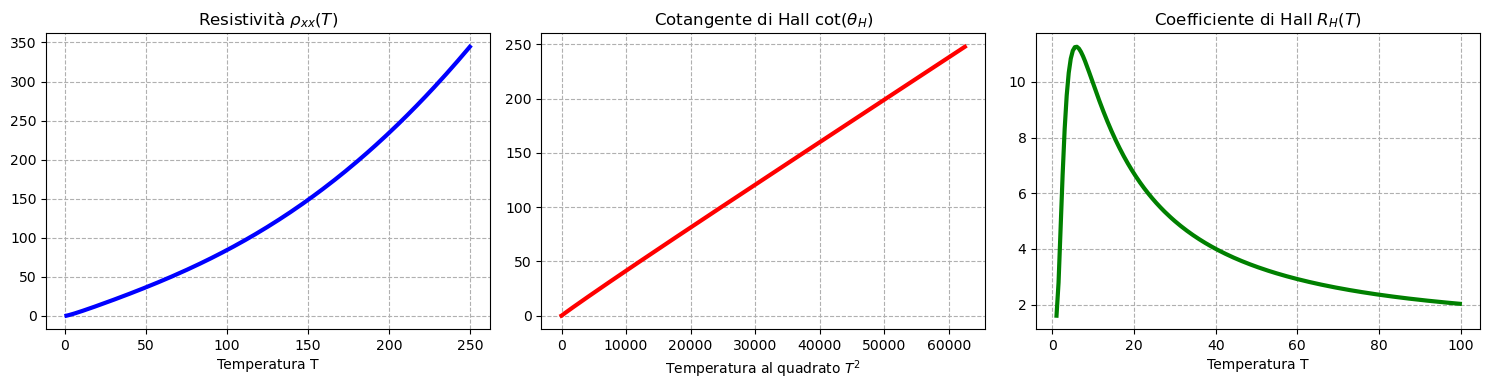

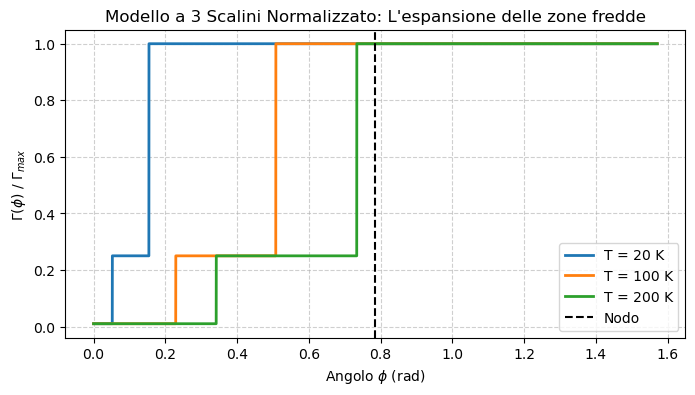

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI
# ==========================================
T_array = np.linspace(1, 250, 500)

phi_max = np.pi / 2
N_points = 100000  # Molto fitto per gestire bene le due derivate dei gradini
phi = np.linspace(0, phi_max, N_points)

rho_xx = np.zeros_like(T_array)
sigma_xy_arr = np.zeros_like(T_array)
cot_theta = np.zeros_like(T_array)
R_H = np.zeros_like(T_array)

# ==========================================
# 2. LOOP SULLA TEMPERATURA
# ==========================================
for i, T in enumerate(T_array):
    
    # --- I TRE LIVELLI DI ATTRITO (Tutti scalano come T^2) ---
    Gamma_1 = 0.002 * (T**2) + 0.01  # Cold-spot (il più conduttivo)
    Gamma_2 = 0.05 * (T**2) + 0.01   # Zona Intermedia (Alone)
    Gamma_3 = 0.2 * (T**2) + 0.01    # Hot-spot (il più resistivo)
    
    # --- GLI ANGOLI CHE SI ALLARGANO (La cinematica di Götz) ---
    # phi_1 è il confine tra Cold e Intermedio. Si espande con T.
    phi_1 = (np.pi / 8) * np.tanh(T / 150.0) 
    
    # phi_2 è il confine tra Intermedio e Hot. Si espande con T, restando sempre > phi_1
    phi_2 = (np.pi / 4) * np.tanh(T / 150.0) + 0.05
    
    # --- COSTRUZIONE DELLA FUNZIONE A 3 GRADINI ---
    Gamma_phi = np.full_like(phi, Gamma_3)   # Riempi tutto con l'hot-spot
    Gamma_phi[phi < phi_2] = Gamma_2         # Sovrascrivi la zona intermedia
    Gamma_phi[phi < phi_1] = Gamma_1         # Sovrascrivi il cold-spot
    
    # --- Integrali di Boltzmann ---
    integrand_xx = (np.cos(phi)**2) / Gamma_phi
    s_xx = np.trapz(integrand_xx, phi)
    
    term_to_derive = np.sin(phi) / Gamma_phi
    derivative_term = np.gradient(term_to_derive, phi)
    integrand_xy = (np.cos(phi) / Gamma_phi) * derivative_term
    s_xy = np.trapz(integrand_xy, phi)
    
    # --- Grandezze Macroscopiche ---
    rho_xx[i] = 1.0 / s_xx
    sigma_xy_arr[i] = s_xy
    cot_theta[i] = s_xx / s_xy
    R_H[i] = s_xy / (s_xx**2)

# ==========================================
# 3. PLOT DEI RISULTATI MACROSCOPICI
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(T_array, rho_xx, 'b-', lw=3)
axs[0].set_title(r'Resistività $\rho_{xx}(T)$')
axs[0].set_xlabel('Temperatura T')
axs[0].grid(True, linestyle='--')

axs[1].plot(T_array**2, cot_theta, 'r-', lw=3) 
axs[1].set_title(r'Cotangente di Hall $\cot(\theta_H)$')
axs[1].set_xlabel('Temperatura al quadrato $T^2$')
axs[1].grid(True, linestyle='--')

mask = T_array <= 100
axs[2].plot(T_array[mask], R_H[mask], 'g-', lw=3)
axs[2].set_title(r'Coefficiente di Hall $R_H(T)$')
axs[2].set_xlabel('Temperatura T')
axs[2].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

# ==========================================
# 4. PLOT BONUS: La mappa a 3 gradini
# ==========================================
plt.figure(figsize=(8, 4))
for T_test in [20, 100, 200]:
    G1 = 0.002 * (T_test**2) + 0.01
    G2 = 0.05 * (T_test**2) + 0.01
    G3 = 0.2 * (T_test**2) + 0.01
    p1 = (np.pi / 8) * np.tanh(T_test / 150.0) 
    p2 = (np.pi / 4) * np.tanh(T_test / 150.0) + 0.05
    
    G_phi = np.full_like(phi, G3)
    G_phi[phi < p2] = G2
    G_phi[phi < p1] = G1
    
    # Plottiamo normalizzato al valore massimo di quella temperatura
    plt.plot(phi, G_phi / G3, label=f'T = {T_test} K', lw=2)

plt.title('Modello a 3 Scalini Normalizzato: L\'espansione delle zone fredde')
plt.xlabel('Angolo $\phi$ (rad)')
plt.ylabel('$\Gamma(\phi)$ / $\Gamma_{max}$')
plt.axvline(np.pi/4, color='black', linestyle='--', label='Nodo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

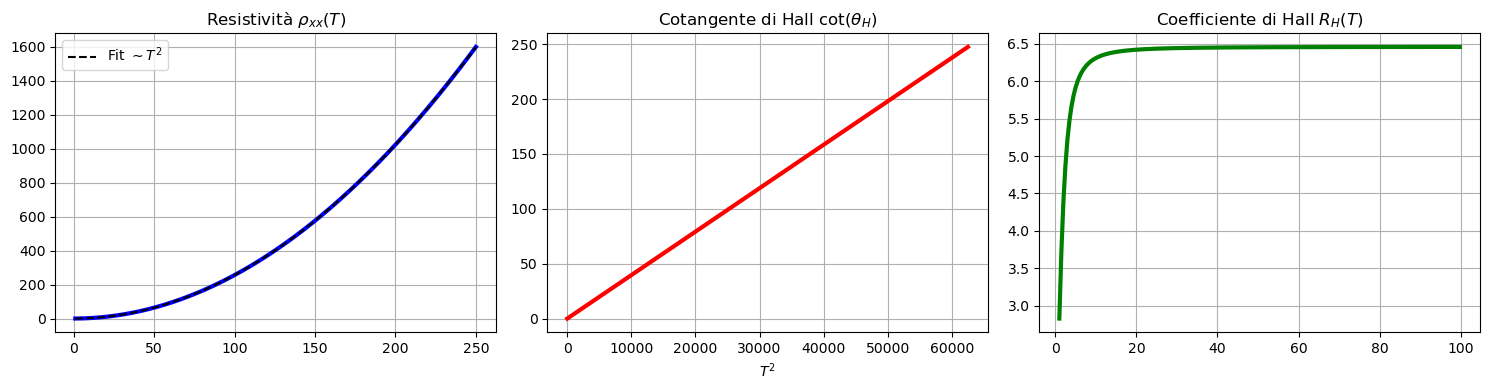

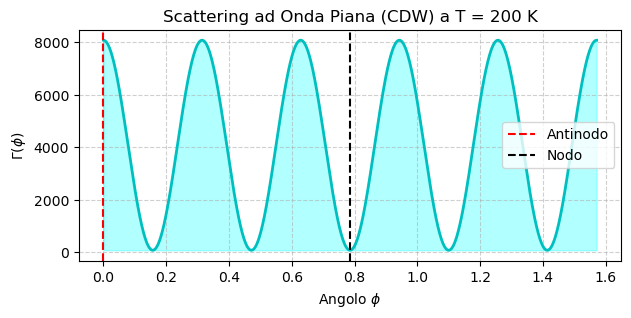

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI
# ==========================================
T_array = np.linspace(1, 250, 500)

phi_max = np.pi / 2
N_points = 50000 
phi = np.linspace(0, phi_max, N_points)

rho_xx = np.zeros_like(T_array)
sigma_xy_arr = np.zeros_like(T_array)
cot_theta = np.zeros_like(T_array)
R_H = np.zeros_like(T_array)

# ==========================================
# 2. LOOP SULLA TEMPERATURA
# ==========================================
for i, T in enumerate(T_array):
    
    # Entrambi gli attriti scalano quadraticamente (Liquido di Fermi)
    Gamma_bg = 0.002 * (T**2) + 0.01  # Il fondo minimo (valli dell'onda)
    A = 0.2 * (T**2)                  # L'ampiezza dell'onda (creste)
    
    # LA NOSTRA ONDA PIANA (CDW Statica)
    # k = 10 crea diverse oscillazioni tra 0 e pi/2.
    # Usiamo il coseno, quindi c'è una "cresta" di attrito esattamente a phi=0 (antinodo)
    k = 10.0
    Gamma_phi = Gamma_bg + A * (np.cos(k * phi)**2)
    
    # --- Integrali di Boltzmann ---
    integrand_xx = (np.cos(phi)**2) / Gamma_phi
    s_xx = np.trapz(integrand_xx, phi)
    
    term_to_derive = np.sin(phi) / Gamma_phi
    derivative_term = np.gradient(term_to_derive, phi)
    integrand_xy = (np.cos(phi) / Gamma_phi) * derivative_term
    s_xy = np.trapz(integrand_xy, phi)
    
    # --- Grandezze Macroscopiche ---
    rho_xx[i] = 1.0 / s_xx
    sigma_xy_arr[i] = s_xy
    cot_theta[i] = s_xx / s_xy
    R_H[i] = s_xy / (s_xx**2)

# ==========================================
# 3. PLOT DEI RISULTATI
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(T_array, rho_xx, 'b-', lw=3)
fit_T2 = rho_xx[0] + (rho_xx[-1]-rho_xx[0]) * (T_array/T_array[-1])**2
axs[0].plot(T_array, fit_T2, 'k--', label=r'Fit $\sim T^2$')
axs[0].set_title(r'Resistività $\rho_{xx}(T)$')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(T_array**2, cot_theta, 'r-', lw=3) 
axs[1].set_title(r'Cotangente di Hall $\cot(\theta_H)$')
axs[1].set_xlabel('$T^2$')
axs[1].grid(True)

mask = T_array <= 100
axs[2].plot(T_array[mask], R_H[mask], 'g-', lw=3)
axs[2].set_title(r'Coefficiente di Hall $R_H(T)$')
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. PLOT BONUS: La forma dell'Onda
# ==========================================
plt.figure(figsize=(7, 3))
T_test = 200
G_bg = 0.002 * (T_test**2) + 0.01
A_test = 0.2 * (T_test**2)
G_phi = G_bg + A_test * (np.cos(k * phi)**2)

plt.plot(phi, G_phi, 'c-', lw=2)
plt.fill_between(phi, G_phi, G_bg, color='cyan', alpha=0.3)
plt.title(f'Scattering ad Onda Piana (CDW) a T = {T_test} K')
plt.xlabel('Angolo $\phi$')
plt.ylabel('$\Gamma(\phi)$')
plt.axvline(0, color='red', linestyle='--', label='Antinodo')
plt.axvline(np.pi/4, color='black', linestyle='--', label='Nodo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

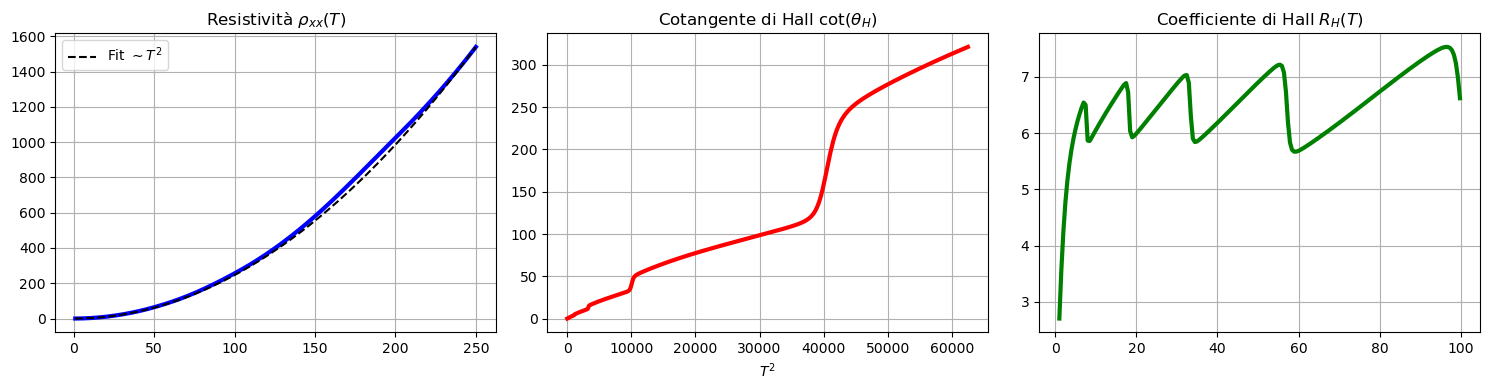

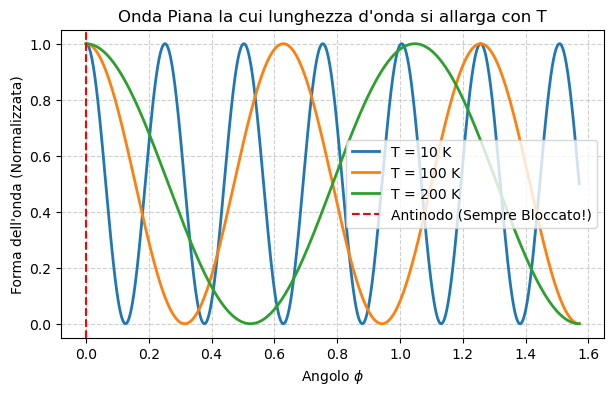

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI
# ==========================================
T_array = np.linspace(1, 250, 500)

phi_max = np.pi / 2
N_points = 50000 
phi = np.linspace(0, phi_max, N_points)

rho_xx = np.zeros_like(T_array)
sigma_xy_arr = np.zeros_like(T_array)
cot_theta = np.zeros_like(T_array)
R_H = np.zeros_like(T_array)

# ==========================================
# 2. LOOP SULLA TEMPERATURA
# ==========================================
for i, T in enumerate(T_array):
    
    # Base Termodinamica (Liquido di Fermi: tutto a T^2)
    Gamma_bg = 0.002 * (T**2) + 0.01  # Le "valli" fredde
    A = 0.2 * (T**2)                  # L'ampiezza delle "creste" calde
    
    # IL TRUCCO DI GÖTZ APPLICATO ALL'ONDA
    # k(T) determina quanto è "stretta" l'onda. 
    # Facciamo in modo che a basse T ci siano tante onde strette (k alto),
    # e ad alte T l'onda si "allarghi" linearmente (k diminuisce).
    # Usiamo un parametro che scala linearmente con T al denominatore:
    k_T = 15.0 / (1.0 + T/50.0) 
    
    # Onda Piana "Dinamica" (CDW che respira con la temperatura)
    # Nota: cos^2(0) = 1, quindi l'hot-spot è SEMPRE piantato a phi=0
    Gamma_phi = Gamma_bg + A * (np.cos(k_T * phi)**2)
    
    # --- Integrali di Boltzmann ---
    integrand_xx = (np.cos(phi)**2) / Gamma_phi
    s_xx = np.trapz(integrand_xx, phi)
    
    term_to_derive = np.sin(phi) / Gamma_phi
    derivative_term = np.gradient(term_to_derive, phi)
    integrand_xy = (np.cos(phi) / Gamma_phi) * derivative_term
    s_xy = np.trapz(integrand_xy, phi)
    
    # --- Grandezze Macroscopiche ---
    rho_xx[i] = 1.0 / s_xx
    sigma_xy_arr[i] = s_xy
    cot_theta[i] = s_xx / s_xy
    R_H[i] = s_xy / (s_xx**2)

# ==========================================
# 3. PLOT DEI RISULTATI
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(T_array, rho_xx, 'b-', lw=3)
fit_T2 = rho_xx[0] + (rho_xx[-1]-rho_xx[0]) * (T_array/T_array[-1])**2
axs[0].plot(T_array, fit_T2, 'k--', label=r'Fit $\sim T^2$')
axs[0].set_title(r'Resistività $\rho_{xx}(T)$')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(T_array**2, cot_theta, 'r-', lw=3) 
axs[1].set_title(r'Cotangente di Hall $\cot(\theta_H)$')
axs[1].set_xlabel('$T^2$')
axs[1].grid(True)

mask = T_array <= 100
axs[2].plot(T_array[mask], R_H[mask], 'g-', lw=3)
axs[2].set_title(r'Coefficiente di Hall $R_H(T)$')
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. PLOT BONUS: Guarda come "respira" l'onda
# ==========================================
plt.figure(figsize=(7, 4))
for T_test in [10, 100, 200]:
    k_test = 15.0 / (1.0 + T_test/50.0) 
    # Plottiamo l'onda normalizzata per vedere solo la geometria
    G_phi = (np.cos(k_test * phi)**2)
    plt.plot(phi, G_phi, label=f'T = {T_test} K', lw=2)

plt.title('Onda Piana la cui lunghezza d\'onda si allarga con T')
plt.xlabel('Angolo $\phi$')
plt.ylabel('Forma dell\'onda (Normalizzata)')
plt.axvline(0, color='red', linestyle='--', label='Antinodo (Sempre Bloccato!)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

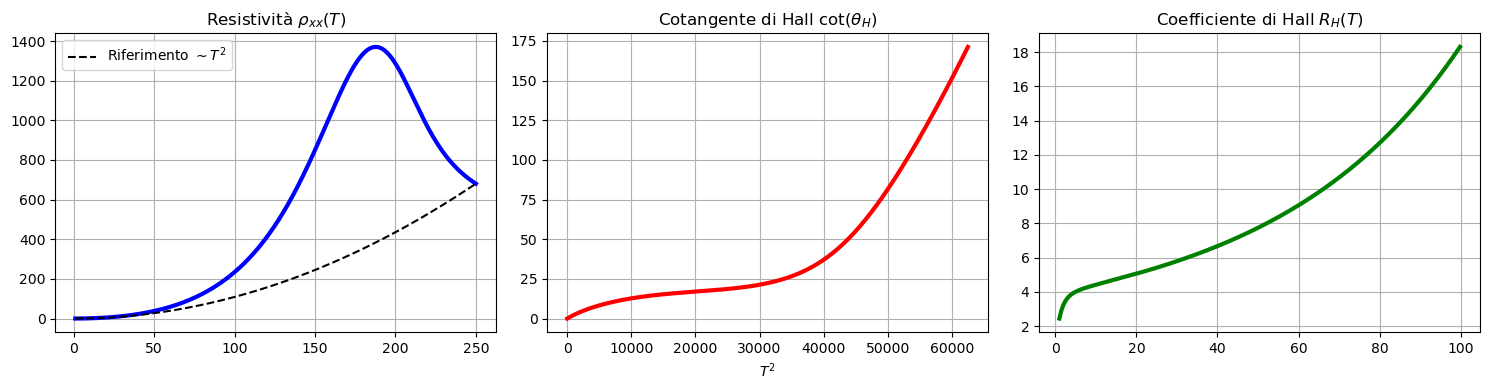

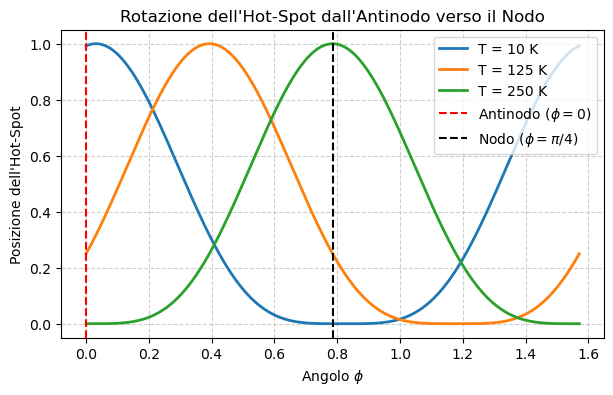

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI
# ==========================================
T_array = np.linspace(1, 250, 500)

phi_max = np.pi / 2
N_points = 50000 
phi = np.linspace(0, phi_max, N_points)

rho_xx = np.zeros_like(T_array)
sigma_xy_arr = np.zeros_like(T_array)
cot_theta = np.zeros_like(T_array)
R_H = np.zeros_like(T_array)

# ==========================================
# 2. LOOP SULLA TEMPERATURA
# ==========================================
for i, T in enumerate(T_array):
    
    # Base Termodinamica (Liquido di Fermi: T^2)
    Gamma_cold = 0.002 * (T**2) + 0.01
    Gamma_hot = 0.2 * (T**2) + 0.01
    
    # LA ROTAZIONE DELL'HOT-SPOT
    # A T=0, shift = 0 (Hot-spot all'antinodo, phi=0)
    # A T=250, shift = pi/4 (Hot-spot al nodo, phi=pi/4)
    phi_shift = (np.pi / 4) * (T / 250.0)
    
    # Funzione di scattering con fase rotante
    # Usiamo un esponente fisso (es. 4) per mantenere la larghezza della campana costante
    Gamma_phi = Gamma_cold + Gamma_hot * (np.abs(np.cos(2 * (phi - phi_shift)))**4)
    
    # --- Integrali di Boltzmann ---
    integrand_xx = (np.cos(phi)**2) / Gamma_phi
    s_xx = np.trapz(integrand_xx, phi)
    
    term_to_derive = np.sin(phi) / Gamma_phi
    derivative_term = np.gradient(term_to_derive, phi)
    integrand_xy = (np.cos(phi) / Gamma_phi) * derivative_term
    s_xy = np.trapz(integrand_xy, phi)
    
    # --- Grandezze Macroscopiche ---
    rho_xx[i] = 1.0 / s_xx
    sigma_xy_arr[i] = s_xy
    cot_theta[i] = s_xx / s_xy
    R_H[i] = s_xy / (s_xx**2)

# ==========================================
# 3. PLOT DEI RISULTATI
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(T_array, rho_xx, 'b-', lw=3)
# Fit per far vedere la curvatura anomala
fit_T2 = rho_xx[0] + (rho_xx[-1]-rho_xx[0]) * (T_array/T_array[-1])**2
axs[0].plot(T_array, fit_T2, 'k--', label=r'Riferimento $\sim T^2$')
axs[0].set_title(r'Resistività $\rho_{xx}(T)$')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(T_array**2, cot_theta, 'r-', lw=3) 
axs[1].set_title(r'Cotangente di Hall $\cot(\theta_H)$')
axs[1].set_xlabel('$T^2$')
axs[1].grid(True)

mask = T_array <= 100
axs[2].plot(T_array[mask], R_H[mask], 'g-', lw=3)
axs[2].set_title(r'Coefficiente di Hall $R_H(T)$')
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. PLOT BONUS: La Danza dell'Hot-Spot
# ==========================================
plt.figure(figsize=(7, 4))
for T_test in [10, 125, 250]:
    shift = (np.pi / 4) * (T_test / 250.0)
    # Plottiamo normalizzato per vedere solo il movimento geometrico
    G_phi = (np.abs(np.cos(2 * (phi - shift)))**4)
    plt.plot(phi, G_phi, label=f'T = {T_test} K', lw=2)

plt.title('Rotazione dell\'Hot-Spot dall\'Antinodo verso il Nodo')
plt.xlabel('Angolo $\phi$')
plt.ylabel('Posizione dell\'Hot-Spot')
plt.axvline(0, color='red', linestyle='--', label='Antinodo ($\phi=0$)')
plt.axvline(np.pi/4, color='black', linestyle='--', label='Nodo ($\phi=\pi/4$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

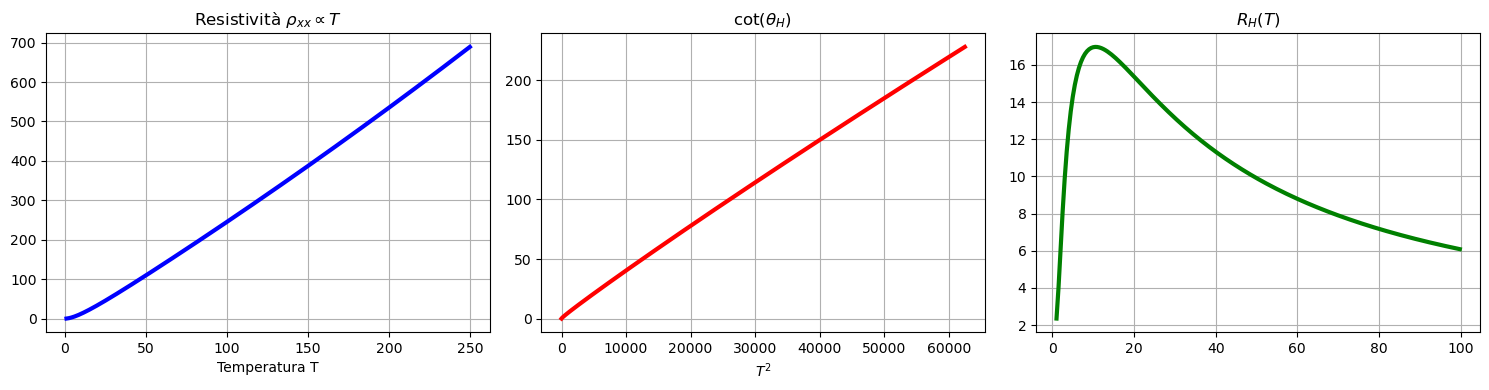

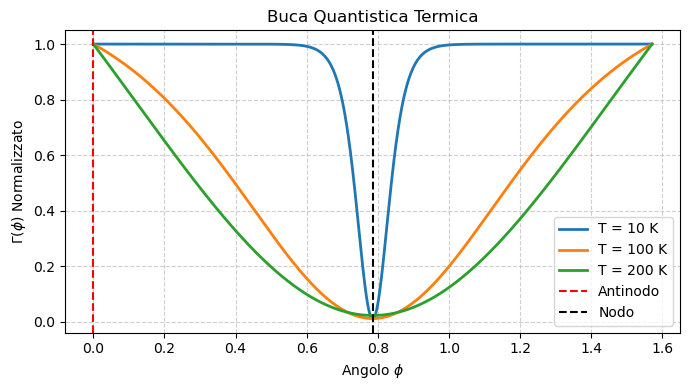

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI
# ==========================================
T_array = np.linspace(1, 250, 500)

phi_max = np.pi / 2
N_points = 50000 
phi = np.linspace(0, phi_max, N_points)

rho_xx = np.zeros_like(T_array)
sigma_xy_arr = np.zeros_like(T_array)
cot_theta = np.zeros_like(T_array)
R_H = np.zeros_like(T_array)

# ==========================================
# 2. LOOP SULLA TEMPERATURA
# ==========================================
for i, T in enumerate(T_array):
    
    # 1. Background Termodinamico a T^2
    Gamma_cold = 0.002 * (T**2) + 0.01  # Il fondo della buca
    Gamma_hot = 0.2 * (T**2) + 0.01     # I bordi (hot-spot)
    
    # 2. Allargamento attorno al nodo
    w_T = (T / 200.0) + 0.01 
    
    # 3. Buca di Tanh centrata sul nodo a pi/4
    # A phi = pi/4, tanh(0) = 0 -> Gamma = Gamma_cold
    # Lontano da pi/4, tanh(inf) = 1 -> Gamma = Gamma_cold + Gamma_hot
    Gamma_phi = Gamma_cold + Gamma_hot * np.tanh((phi - np.pi/4) / w_T)**2
    
    # --- Integrali di Boltzmann ---
    integrand_xx = (np.cos(phi)**2) / Gamma_phi
    s_xx = np.trapz(integrand_xx, phi)
    
    term_to_derive = np.sin(phi) / Gamma_phi
    derivative_term = np.gradient(term_to_derive, phi)
    integrand_xy = (np.cos(phi) / Gamma_phi) * derivative_term
    s_xy = np.trapz(integrand_xy, phi)
    
    # --- Grandezze Macroscopiche ---
    rho_xx[i] = 1.0 / s_xx
    sigma_xy_arr[i] = s_xy
    cot_theta[i] = s_xx / s_xy
    R_H[i] = s_xy / (s_xx**2)

# ==========================================
# 3. PLOT 
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(T_array, rho_xx, 'b-', lw=3)
axs[0].set_title(r'Resistività $\rho_{xx} \propto T$')
axs[0].set_xlabel('Temperatura T')
axs[0].grid(True)

axs[1].plot(T_array**2, cot_theta, 'r-', lw=3) 
axs[1].set_title(r'$\cot(\theta_H)$ ')
axs[1].set_xlabel('$T^2$')
axs[1].grid(True)

mask = T_array <= 100
axs[2].plot(T_array[mask], R_H[mask], 'g-', lw=3)
axs[2].set_title(r'$R_H(T)$')
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. PLOT BONUS: La Buca che Respira
# ==========================================
plt.figure(figsize=(7, 4))
for T_test in [10, 100, 200]:
    Gc = 0.002 * (T_test**2) + 0.01
    Gh = 0.2 * (T_test**2) + 0.01
    w = (T_test / 200.0) + 0.01
    G_phi = Gc + Gh * np.tanh((phi - np.pi/4) / w)**2
    
    # Plottiamo normalizzato per vedere la fessura che si apre
    plt.plot(phi, G_phi / np.max(G_phi), label=f'T = {T_test} K', lw=2)

plt.title('Buca Quantistica Termica')
plt.xlabel('Angolo $\phi$')
plt.ylabel('$\Gamma(\phi)$ Normalizzato')
plt.axvline(0, color='red', linestyle='--', label='Antinodo')
plt.axvline(np.pi/4, color='black', linestyle='--', label='Nodo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Immagine 'Analisi_Trasporto_Completa.png' salvata con successo!


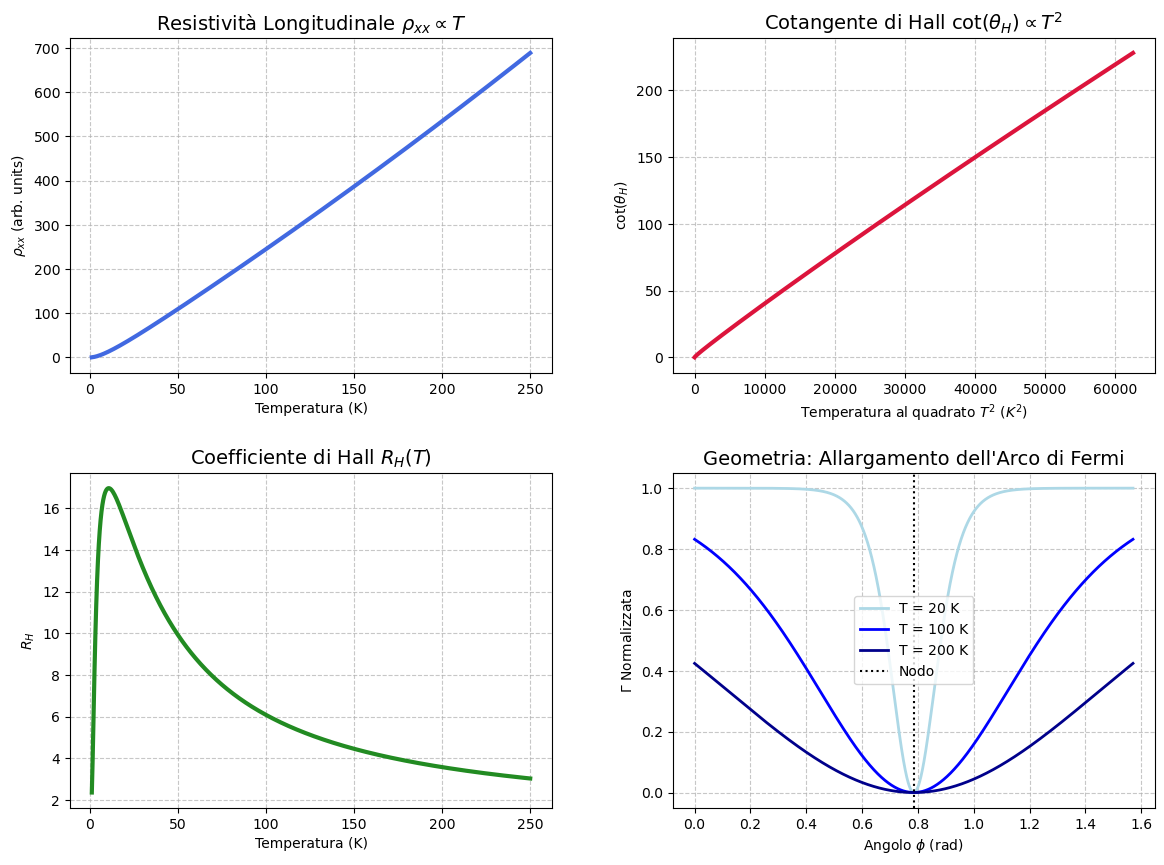

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPOSTAZIONE DEI PARAMETRI
# ==========================================
T_array = np.linspace(1, 250, 500)
phi_max = np.pi / 2
N_points = 50000 
phi = np.linspace(0, phi_max, N_points)

rho_xx = np.zeros_like(T_array)
sigma_xy_arr = np.zeros_like(T_array)
cot_theta = np.zeros_like(T_array)
R_H = np.zeros_like(T_array)

# ==========================================
# 2. LOOP SULLA TEMPERATURA
# ==========================================
for i, T in enumerate(T_array):
    Gamma_cold = 0.002 * (T**2) + 0.01
    Gamma_hot = 0.2 * (T**2) + 0.01
    w_T = (T / 200.0) + 0.01 
    
    # La nostra Buca di Tanh al nodo (pi/4)
    Gamma_phi = Gamma_cold + Gamma_hot * np.tanh((phi - np.pi/4) / w_T)**2
    
    # Integrali
    s_xx = np.trapz((np.cos(phi)**2) / Gamma_phi, phi)
    term_to_derive = np.sin(phi) / Gamma_phi
    s_xy = np.trapz((np.cos(phi) / Gamma_phi) * np.gradient(term_to_derive, phi), phi)
    
    rho_xx[i] = 1.0 / s_xx
    cot_theta[i] = s_xx / s_xy
    R_H[i] = s_xy / (s_xx**2)

# ==========================================
# 3. CREAZIONE DELLA FIGURA 2x2
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# --- Grafico 1: Resistività ---
axs[0, 0].plot(T_array, rho_xx, color='royalblue', lw=3)
axs[0, 0].set_title(r'Resistività Longitudinale $\rho_{xx} \propto T$', fontsize=14)
axs[0, 0].set_xlabel('Temperatura (K)')
axs[0, 0].set_ylabel(r'$\rho_{xx}$ (arb. units)')
axs[0, 0].grid(True, linestyle='--', alpha=0.7)

# --- Grafico 2: Cotangente di Hall ---
axs[0, 1].plot(T_array**2, cot_theta, color='crimson', lw=3)
axs[0, 1].set_title(r'Cotangente di Hall $\cot(\theta_H) \propto T^2$', fontsize=14)
axs[0, 1].set_xlabel('Temperatura al quadrato $T^2$ ($K^2$)')
axs[0, 1].set_ylabel(r'$\cot(\theta_H)$')
axs[0, 1].grid(True, linestyle='--', alpha=0.7)

# --- Grafico 3: Coefficiente di Hall ---
axs[1, 0].plot(T_array, R_H, color='forestgreen', lw=3)
axs[1, 0].set_title(r'Coefficiente di Hall $R_H(T)$', fontsize=14)
axs[1, 0].set_xlabel('Temperatura (K)')
axs[1, 0].set_ylabel(r'$R_H$')
axs[1, 0].grid(True, linestyle='--', alpha=0.7)

# --- Grafico 4: La Fisica (La Buca di Tanh) ---
for T_test, col in zip([20, 100, 200], ['lightblue', 'blue', 'darkblue']):
    w = (T_test / 200.0) + 0.01
    G_shape = np.tanh((phi - np.pi/4) / w)**2
    axs[1, 1].plot(phi, G_shape, label=f'T = {T_test} K', color=col, lw=2)

axs[1, 1].set_title('Geometria: Allargamento dell\'Arco di Fermi', fontsize=14)
axs[1, 1].set_xlabel('Angolo $\phi$ (rad)')
axs[1, 1].set_ylabel(r'$\Gamma$ Normalizzata')
axs[1, 1].axvline(np.pi/4, color='black', linestyle=':', label='Nodo')
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle='--', alpha=0.7)

# ==========================================
# 4. SALVATAGGIO FINALE
# ==========================================
plt.savefig('Analisi_Trasporto_Completa.png', dpi=300, bbox_inches='tight')
print("Immagine 'Analisi_Trasporto_Completa.png' salvata con successo!")
plt.show()